In [13]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
import cv2
from tensorflow.keras import layers, models

In [4]:
dataset, info = tfds.load('oxford_iiit_pet:4.*.*', with_info=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.1T6ZT2_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.1T6ZT2_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.


In [5]:
train_data = dataset['train']
test_data = dataset['test']

In [8]:
IMG_SIZE = 128
BATCH_SIZE = 16
# preprocessing (resizing and scaling)

In [9]:
def preprocess(data):
    image = data['image']
    mask = data['segmentation_mask']
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    mask = tf.image.resize(mask, (IMG_SIZE, IMG_SIZE))
    print(mask)
    image = tf.cast(image, tf.float32) / 255.0
    return image, mask

In [10]:
train_data = train_data.map(preprocess).cache().shuffle(1000).batch(BATCH_SIZE)

Tensor("resize_1/Squeeze:0", shape=(128, 128, 1), dtype=float32)


(16, 128, 128, 3)
(16, 128, 128, 1)


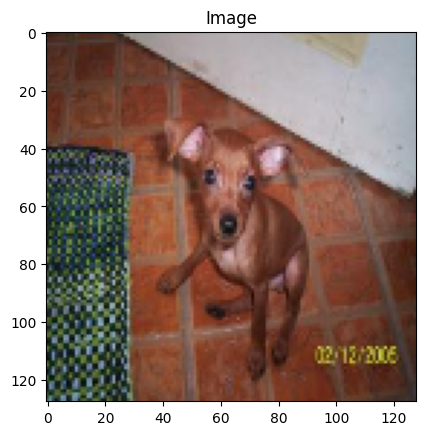

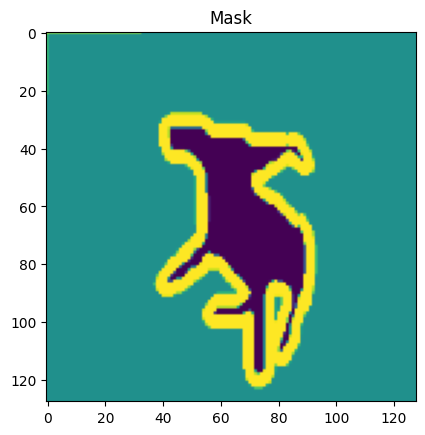

In [12]:
for images, masks in train_data.take(1):
    print(images.shape)
    print(masks.shape)
    plt.title('Image')
    plt.imshow(images[0])
    plt.figure()
    plt.title('Mask')
    plt.imshow(masks[0])

In [14]:
def conv_block(x,num_filters):
    x = layers.Conv2D(num_filters, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(num_filters, 3, padding='same', activation='relu')(x)
    return x

In [15]:
def encoder_block(x,num_filters):
    f = conv_block(x,num_filters)
    p = layers.MaxPool2D((2,2))(f)
    return f,p

In [ ]:
def decoder_block(x, skip_features, num_filters):
    x = layers.Conv2DTranspose(num_filters, (2,2), strides=2, padding='same')(x)
    x = layers.Concatenate()([x, skip_features])
    x = conv_block(x,num_filters)
    return x